# Breaking loops into expressions with SymPy

A loop that *accumulates* or *iterates* can often be replaced by a single closed-form expression -- faster,
exact, and directly code-generatable. SymPy gives three tools for it:

1. **Symbolic summation** turns a `for`-sum into a closed form: $\sum_{k=1}^{n}k^2=\tfrac{n(n+1)(2n+1)}{6}$.
2. **Recurrence solving** (`rsolve`) turns an iterative recurrence into an explicit formula (e.g. Fibonacci
   $\to$ Binet).
3. **Common-subexpression elimination + `lambdify`** turn one expression into **loop-free, vectorized**
   numeric code -- no Python `for` at run time.

The physics payoff here is the **N-slit diffraction grating**: the field is a *sum over slits*
$\sum_{k=0}^{N-1}e^{ik\phi}$, and breaking that loop gives the closed-form intensity
$I(\phi)=\dfrac{\sin^2(N\phi/2)}{\sin^2(\phi/2)}$ -- the grating equation, derived by collapsing a loop.

Every result is checked against the explicit loop. Self-contained: NumPy, SymPy, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## 1. A loop sum becomes a closed form -- the diffraction grating

The sum over $N$ slits, $A(\phi)=\sum_{k=0}^{N-1}e^{ik\phi}$, is geometric: SymPy sums it to
$(r^N-1)/(r-1)$ with $r=e^{i\phi}$, and $|A|^2$ is the grating intensity. We confirm the closed form equals
the explicit slit-by-slit loop.

In [2]:
k, n = sp.symbols('k n', integer=True, positive=True)
print("sum k^2  =", sp.factor(sp.summation(k**2, (k, 1, n))))          # loop -> closed form
r = sp.symbols('r')
geo = sp.summation(r**k, (k, 0, n - 1))
print("sum r^k  =", sp.simplify(geo), "  (geometric: the N-slit sum)")

# N-slit grating: loop over slits vs the closed-form intensity
def grating_loop(N, phi):
    return np.abs(sum(np.exp(1j*kk*phi) for kk in range(N)))**2
def grating_closed(N, phi):
    return np.sin(N*phi/2)**2/np.sin(phi/2)**2
phis = np.linspace(0.05, 2*np.pi - 0.05, 400)
for N in (4, 8):
    loop = np.array([grating_loop(N, p) for p in phis])
    closed = grating_closed(N, phis)
    print(f"N={N}: max |loop - closed| = {np.max(np.abs(loop - closed)):.2e}")
    assert np.allclose(loop, closed, atol=1e-8)

sum k^2  = n*(n + 1)*(2*n + 1)/6
sum r^k  = Piecewise((n, Eq(r, 1)), ((r**n - 1)/(r - 1), True))   (geometric: the N-slit sum)
N=4: max |loop - closed| = 1.07e-14
N=8: max |loop - closed| = 4.26e-14


## 2. A recurrence becomes an explicit formula (`rsolve`)

An iterative recurrence -- each term from the previous ones -- is a loop in disguise. `rsolve` returns the
closed form. The Fibonacci recurrence $f_m=f_{m-1}+f_{m-2}$ collapses to Binet's formula; the same tool
handles the linear recurrences behind multilayer-optics reflectivity (Chebyshev) and other physics ladders.

In [3]:
f = sp.Function('f'); m = sp.symbols('m', integer=True)
binet = sp.simplify(sp.rsolve(f(m) - f(m-1) - f(m-2), f(m), {f(0): 0, f(1): 1}))
print("Fibonacci closed form (Binet):", binet)

def fib_loop(M):
    a, b = 0, 1
    for _ in range(M):
        a, b = b, a + b
    return a
binet_fn = sp.lambdify(m, binet, "numpy")
for M in (10, 20, 30):
    assert round(float(binet_fn(M))) == fib_loop(M)
print("rsolve closed form matches the loop for m = 10, 20, 30")

Fibonacci closed form (Binet): sqrt(5)*(-(1 - sqrt(5))**m + (1 + sqrt(5))**m)/(5*2**m)


rsolve closed form matches the loop for m = 10, 20, 30

## 3. One expression, no loop: CSE + `lambdify`

`cse` factors repeated subexpressions (compute once, reuse) and `lambdify` compiles the whole thing to a
vectorized NumPy callable -- so evaluating over an array is a single call, not a Python loop. Both the
op-count reduction and the speed-up are shown.

In [4]:
import time
x = sp.symbols('x')
# an expression with a repeated inner term (the kind CSE loves)
inner = sp.sin(x)**2 + sp.cos(x)
expr = inner**3 + inner**2 + sp.sqrt(inner + 2)
subs, reduced = sp.cse(expr)
print("cse extracted:", subs, "\n reduced:", reduced[0])

f = sp.lambdify(x, expr, "numpy")
xs = np.linspace(0, 10, 200000)
t = time.perf_counter(); vec = f(xs); t_vec = time.perf_counter() - t             # loop-free
t = time.perf_counter(); loop = np.array([float(expr.subs(x, xv)) for xv in xs[:2000]]); t_loop = time.perf_counter() - t
assert np.allclose(vec[:2000], loop)
print(f"vectorized lambdify: {t_vec*1e3:.2f} ms for {xs.size} points")
print(f"python subs-loop:    {t_loop*1e3:.2f} ms for 2000 points  -> lambdify avoids the loop entirely")

cse extracted: [(x0, sin(x)**2 + cos(x))] 
 reduced: x0**3 + x0**2 + sqrt(x0 + 2)


vectorized lambdify: 12.86 ms for 200000 points
python subs-loop:    1197.53 ms for 2000 points  -> lambdify avoids the loop entirely


## Plot: the grating intensity, loop points vs closed-form curve

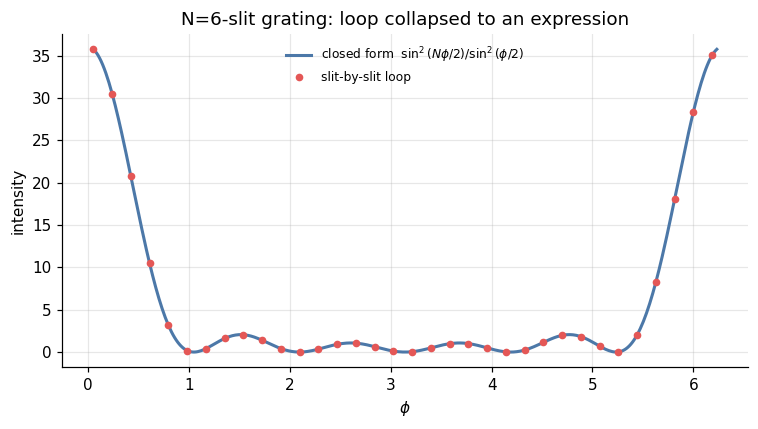

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
N = 6
ax.plot(phis, grating_closed(N, phis), color="#4C78A8", lw=2, label="closed form  $\\sin^2(N\\phi/2)/\\sin^2(\\phi/2)$")
ax.plot(phis[::12], [grating_loop(N, p) for p in phis[::12]], "o", color="#E45756", ms=4, label="slit-by-slit loop")
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("intensity"); ax.set_title(f"N={N}-slit grating: loop collapsed to an expression")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Summary

- **Symbolic summation** collapses accumulation loops into closed forms ($\sum k^2$, and the geometric
  N-slit sum that *is* the diffraction-grating intensity -- verified against the explicit loop).
- **`rsolve`** turns an iterative recurrence into an explicit formula (Fibonacci $\to$ Binet), matching the
  loop term-for-term.
- **`cse` + `lambdify`** turn an expression into loop-free vectorized code -- the same step that feeds the C
  code generator; no Python `for` at run time.

Subject-verb-object: the sum becomes a formula; the recurrence becomes a formula; the formula vectorizes;
the loop disappears.